# **Day 58: Neural Networks From Scratch**
*Module 10 - Deep Learning Foundations*

Deep learning starts here. A neural network is a chain of **linear transformations** and **non-linear activations**, trained by **gradient descent** with gradients from **backpropagation** (the chain rule, Day 8). Before using PyTorch tomorrow, we build a complete multi-layer perceptron (MLP) in NumPy so nothing is magic.

> A neural network is layers of simple units: each computes a weighted sum and applies a non-linear function. Building one from scratch with NumPy shows exactly how forward passes, losses and backpropagation work.
>
> *Example:* A network with one hidden layer can learn the curved boundary between water and land in (NDWI, NIR) space, which a single straight line cannot.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(58)

## **1. The Perceptron (Rosenblatt, 1958)**
$\hat y = \text{step}(\mathbf w^\top\mathbf x + b)$. Learning rule: if wrong, $\mathbf w \leftarrow \mathbf w + \eta\,(y - \hat y)\,\mathbf x$. It converges for linearly separable data, but **cannot** learn XOR (Minsky & Papert, 1969): no straight line separates XOR.

In [2]:
def perceptron(X, y, epochs=50, lr=0.1):
    w, b = np.zeros(X.shape[1]), 0.0
    for _ in range(epochs):
        for xi, yi in zip(X, y):
            pred = int(xi @ w + b > 0); w += lr * (yi - pred) * xi; b += lr * (yi - pred)
    return w, b
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]); y_and = np.array([0, 0, 0, 1]); y_xor = np.array([0, 1, 1, 0])
for name, yy in [("AND", y_and), ("XOR", y_xor)]:
    w, b = perceptron(X_and, yy)
    print(f"{name}: predictions {(X_and @ w + b > 0).astype(int)} | target {yy}")

AND: predictions [0 0 0 1] | target [0 0 0 1]
XOR: predictions [1 1 0 0] | target [0 1 1 0]


## **2. The Multi-Layer Perceptron**
Stack layers: $\mathbf h^{(1)} = g(W^{(1)}\mathbf x + \mathbf b^{(1)})$, $\mathbf h^{(2)} = g(W^{(2)}\mathbf h^{(1)} + \mathbf b^{(2)})$, ..., output $= \text{softmax}(W^{(L)}\mathbf h^{(L-1)} + \mathbf b^{(L)})$. The non-linearity $g$ (ReLU, tanh) is essential: without it, the whole network collapses to one linear map.

| Activation | $g(z)$ | $g'(z)$ | Notes |
|---|---|---|---|
| Sigmoid | $1/(1+e^{-z})$ | $g(1-g)$ | saturates; used for binary outputs |
| tanh | $\tanh z$ | $1 - g^2$ | zero-centred; saturates |
| **ReLU** | $\max(0, z)$ | $1[z>0]$ | default for hidden layers; fast; no saturation for $z>0$ |
| Leaky ReLU / GELU | ... | ... | avoid "dead" ReLUs; GELU in transformers |

## **3. Backpropagation**
For a batch with softmax output $P$ and one-hot labels $Y$, the cross-entropy gradient at the output pre-activation is simply $\frac{1}{n}(P - Y)$ (Day 8). Going backwards through layer $l$ with $Z^{(l)} = A^{(l-1)}W^{(l)} + \mathbf b^{(l)}$, $A^{(l)} = g(Z^{(l)})$:
$$\frac{\partial L}{\partial W^{(l)}} = A^{(l-1)\top}\delta^{(l)},\quad \frac{\partial L}{\partial \mathbf b^{(l)}} = \textstyle\sum_i\delta_i^{(l)},\quad \delta^{(l-1)} = \big(\delta^{(l)}W^{(l)\top}\big)\odot g'(Z^{(l-1)})$$

In [3]:
class MLP:
    """A fully-connected network with ReLU hidden layers and a softmax output, trained by mini-batch SGD."""
    def __init__(self, sizes, seed=0):
        r = np.random.default_rng(seed)
        self.W = [r.normal(0, np.sqrt(2 / m), (m, n)) for m, n in zip(sizes[:-1], sizes[1:])]   # He initialisation (Day 61)
        self.b = [np.zeros(n) for n in sizes[1:]]

    @staticmethod
    def softmax(Z):
        Z = Z - Z.max(1, keepdims=True); E = np.exp(Z); return E / E.sum(1, keepdims=True)

    def loss_and_grads(self, X, y):
        n = len(X); acts, Zs, A = [X], [], X
        for l, (W, b) in enumerate(zip(self.W, self.b)):           # forward pass, storing what backprop needs
            Z = A @ W + b; Zs.append(Z)
            A = self.softmax(Z) if l == len(self.W) - 1 else np.maximum(0, Z); acts.append(A)
        P = acts[-1]
        loss = -np.mean(np.log(P[np.arange(n), y] + 1e-12))
        delta = P.copy(); delta[np.arange(n), y] -= 1; delta /= n   # dL/dZ at the output = (P - Y)/n
        gW, gb = [None] * len(self.W), [None] * len(self.W)
        for l in reversed(range(len(self.W))):                      # backward pass
            gW[l] = acts[l].T @ delta; gb[l] = delta.sum(0)
            if l > 0:
                delta = (delta @ self.W[l].T) * (Zs[l - 1] > 0)    # chain rule through ReLU
        return loss, gW, gb

    def predict_proba(self, X):
        A = X
        for l, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A @ W + b; A = self.softmax(Z) if l == len(self.W) - 1 else np.maximum(0, Z)
        return A

    def fit(self, X, y, X_val=None, y_val=None, epochs=100, lr=0.1, batch=32, l2=0.0, seed=0):
        r = np.random.default_rng(seed); self.history = []
        for ep in range(epochs):
            idx = r.permutation(len(X))
            for s in range(0, len(X), batch):
                bi = idx[s:s + batch]
                _, gW, gb = self.loss_and_grads(X[bi], y[bi])
                for l in range(len(self.W)):
                    self.W[l] -= lr * (gW[l] + l2 * self.W[l]); self.b[l] -= lr * gb[l]
            tr_loss = self.loss_and_grads(X, y)[0]
            va_acc = np.mean(self.predict_proba(X_val).argmax(1) == y_val) if X_val is not None else np.nan
            self.history.append((tr_loss, np.mean(self.predict_proba(X).argmax(1) == y), va_acc))
        return self

### Gradient checking
Before trusting backprop, compare analytical gradients with finite differences (Day 8).

In [4]:
net = MLP([4, 6, 5, 3], seed=1)
Xc = rng.normal(size=(10, 4)); yc = rng.integers(0, 3, 10)
_, gW, gb = net.loss_and_grads(Xc, yc)
eps, max_rel = 1e-6, 0
for l in range(len(net.W)):
    for _ in range(5):
        i, j = rng.integers(net.W[l].shape[0]), rng.integers(net.W[l].shape[1])
        old = net.W[l][i, j]
        net.W[l][i, j] = old + eps; lp = net.loss_and_grads(Xc, yc)[0]
        net.W[l][i, j] = old - eps; lm = net.loss_and_grads(Xc, yc)[0]
        net.W[l][i, j] = old
        num = (lp - lm) / (2 * eps); max_rel = max(max_rel, abs(num - gW[l][i, j]) / (abs(num) + abs(gW[l][i, j]) + 1e-12))
print(f"max relative error between backprop and numerical gradients: {max_rel:.2e}  (< 1e-6 means correct)")

max relative error between backprop and numerical gradients: 3.40e-08  (< 1e-6 means correct)


## **4. Solving XOR and Non-Linear Problems**

XOR predictions: [0 1 1 0] | target: [0 1 1 0]


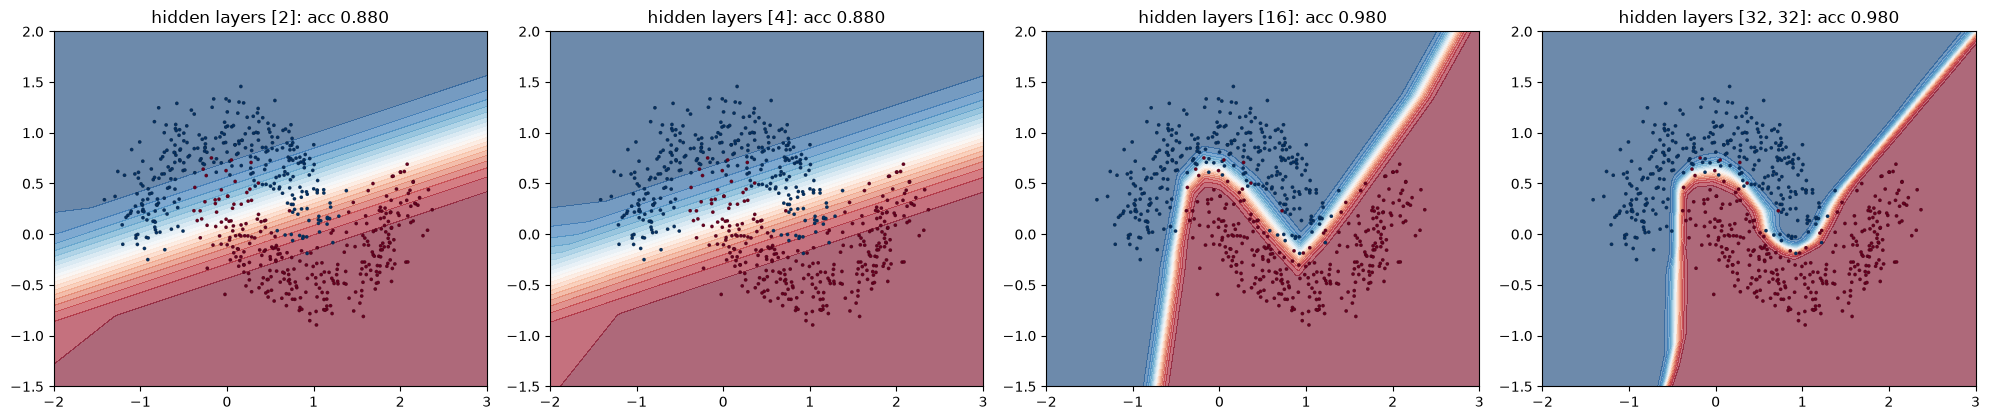

In [5]:
xor_net = MLP([2, 8, 2], seed=0).fit(X_and.astype(float), y_xor, epochs=2000, lr=0.5, batch=4)
print("XOR predictions:", xor_net.predict_proba(X_and.astype(float)).argmax(1), "| target:", y_xor)

from sklearn.datasets import make_moons, make_circles
fig, axes = plt.subplots(1, 4, figsize=(20, 4.3))
Xm, ym = make_moons(600, noise=0.2, random_state=0)
xx, yy = np.meshgrid(np.linspace(-2, 3, 200), np.linspace(-1.5, 2, 200)); grid = np.c_[xx.ravel(), yy.ravel()]
for ax, hidden in zip(axes, [[2], [4], [16], [32, 32]]):
    m = MLP([2] + hidden + [2], seed=0).fit(Xm, ym, epochs=300, lr=0.1)
    ax.contourf(xx, yy, m.predict_proba(grid)[:, 1].reshape(xx.shape), levels=20, cmap="RdBu_r", alpha=0.6)
    ax.scatter(*Xm.T, c=ym, cmap="RdBu_r", s=6, edgecolor="k", lw=0.1); ax.set_title(f"hidden layers {hidden}: acc {m.history[-1][1]:.3f}")
plt.tight_layout(); plt.show()

## **5. A Real Task: Handwritten Digits**

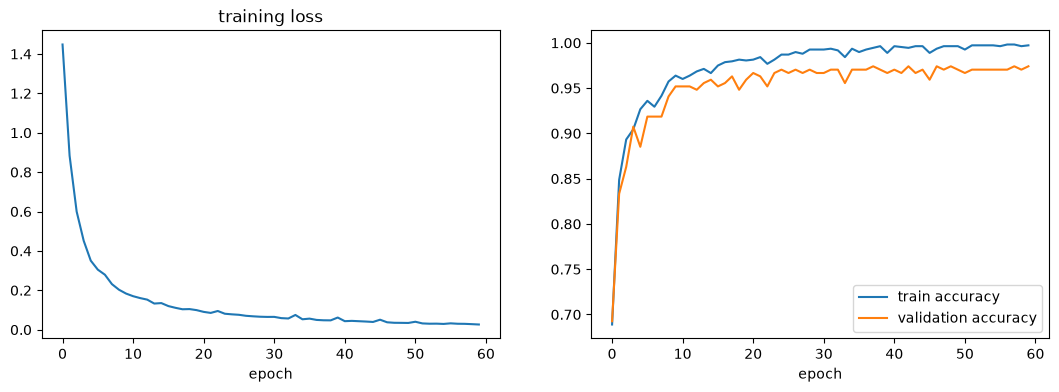

test accuracy 0.969


sklearn MLPClassifier (same architecture) 0.976


In [6]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
X, y = load_digits(return_X_y=True); X = X / 16.0
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)
X_tr, X_va, y_tr, y_va = train_test_split(X_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=0)
net = MLP([64, 128, 64, 10], seed=0).fit(X_tr, y_tr, X_va, y_va, epochs=60, lr=0.05, batch=32)
h = np.array(net.history)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(h[:, 0]); axes[0].set(title="training loss", xlabel="epoch")
axes[1].plot(h[:, 1], label="train accuracy"); axes[1].plot(h[:, 2], label="validation accuracy"); axes[1].legend(); axes[1].set(xlabel="epoch")
plt.show()
print(f"test accuracy {np.mean(net.predict_proba(X_te).argmax(1) == y_te):.3f}")
from sklearn.neural_network import MLPClassifier
print(f"sklearn MLPClassifier (same architecture) {MLPClassifier((128, 64), max_iter=300, random_state=0).fit(X_tr, y_tr).score(X_te, y_te):.3f}")

### What did the first layer learn?

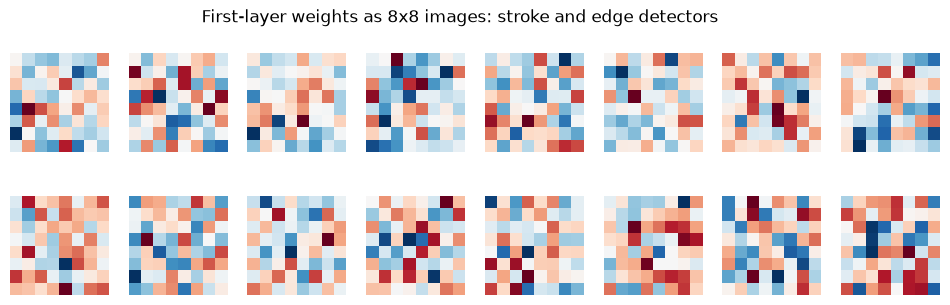

In [7]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for ax, w in zip(axes.ravel(), net.W[0].T[:16]):
    ax.imshow(w.reshape(8, 8), cmap="RdBu_r"); ax.axis("off")
plt.suptitle("First-layer weights as 8x8 images: stroke and edge detectors"); plt.show()

## **6. Universal Approximation**
A network with **one** hidden layer and enough units can approximate any continuous function on a bounded domain arbitrarily well (Cybenko, 1989; Hornik, 1991). It does **not** say how many units are needed, that training will find the weights, or that the network will generalise. In practice, **depth** reaches the same accuracy with far fewer parameters for compositional functions.

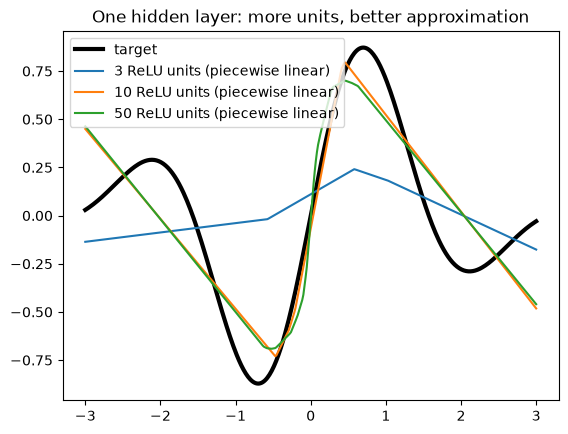

In [8]:
xs = np.linspace(-3, 3, 400)[:, None]; target = np.sin(2 * xs.ravel()) * np.exp(-xs.ravel() ** 2 / 4)
class MLPReg(MLP):
    def loss_and_grads(self, X, y):
        n = len(X); acts, Zs, A = [X], [], X
        for l, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A @ W + b; Zs.append(Z); A = Z if l == len(self.W) - 1 else np.maximum(0, Z); acts.append(A)
        delta = 2 * (acts[-1] - y[:, None]) / n; loss = np.mean((acts[-1].ravel() - y) ** 2)
        gW, gb = [None] * len(self.W), [None] * len(self.W)
        for l in reversed(range(len(self.W))):
            gW[l] = acts[l].T @ delta; gb[l] = delta.sum(0)
            if l > 0: delta = (delta @ self.W[l].T) * (Zs[l - 1] > 0)
        return loss, gW, gb
    def predict(self, X):
        A = X
        for l, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A @ W + b; A = Z if l == len(self.W) - 1 else np.maximum(0, Z)
        return A.ravel()
plt.plot(xs, target, "k", lw=3, label="target")
for hidden in [3, 10, 50]:
    m = MLPReg([1, hidden, 1], seed=0)
    for ep in range(3000):
        _, gW, gb = m.loss_and_grads(xs, target)
        for l in range(2): m.W[l] -= 0.01 * gW[l]; m.b[l] -= 0.01 * gb[l]
    plt.plot(xs, m.predict(xs), label=f"{hidden} ReLU units (piecewise linear)")
plt.legend(); plt.title("One hidden layer: more units, better approximation"); plt.show()

# **Part 2: Going Deeper - Why Depth and Initialisation Matter**

A ReLU network is a **piecewise-linear** function. The number of linear pieces can grow **exponentially with depth** but only polynomially with width (Montufar et al., 2014): depth gives expressive power cheaply. But deep networks are harder to train: gradients can **vanish or explode** as they pass through many layers (Day 61). Let us measure gradient norms per layer with a bad (too small) and a good (He) initialisation.

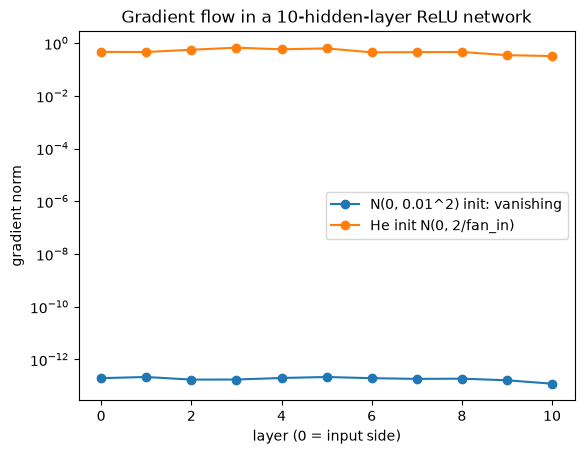

In [9]:
def grad_norms(init_scale, depth=10, width=64):
    m = MLP([64] + [width] * depth + [10], seed=0)
    if init_scale is not None:
        m.W = [rng.normal(0, init_scale, W.shape) for W in m.W]
    _, gW, _ = m.loss_and_grads(X_tr[:256], y_tr[:256])
    return [np.linalg.norm(g) for g in gW]
plt.semilogy(grad_norms(0.01), "o-", label="N(0, 0.01^2) init: vanishing")
plt.semilogy(grad_norms(None), "o-", label="He init N(0, 2/fan_in)")
plt.xlabel("layer (0 = input side)"); plt.ylabel("gradient norm"); plt.legend(); plt.title("Gradient flow in a 10-hidden-layer ReLU network"); plt.show()

## **Practice Problems**
1. Replace ReLU by tanh in the MLP (forward and derivative) and train on the digits. Compare convergence.
2. Add L2 weight decay (`l2=1e-3`) to the digits model. Does validation accuracy change?
3. Train the digits MLP with learning rates 0.001, 0.05 and 1.0 and plot the training loss curves.
4. *(Advanced)* Implement **momentum** in `MLP.fit` (Day 13) and compare epochs needed to reach 95% validation accuracy.

tanh MLP test accuracy 0.969


with L2: best val acc 0.974 vs 0.974


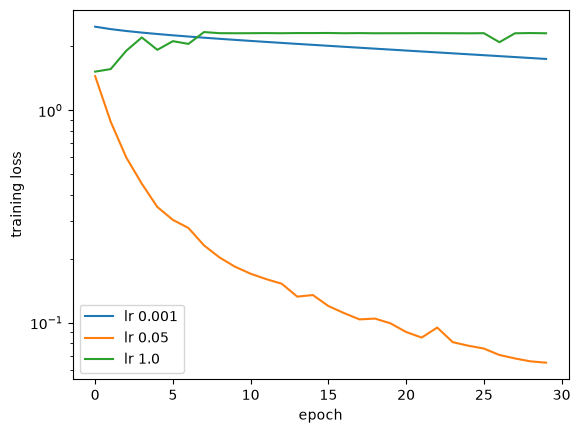

epochs to 95% val accuracy: plain SGD 10 | momentum 6


In [10]:
# Solution 1
class TanhMLP(MLP):
    def loss_and_grads(self, X, y):
        n = len(X); acts, A = [X], X
        for l, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A @ W + b; A = self.softmax(Z) if l == len(self.W) - 1 else np.tanh(Z); acts.append(A)
        P = acts[-1]; loss = -np.mean(np.log(P[np.arange(n), y] + 1e-12))
        delta = P.copy(); delta[np.arange(n), y] -= 1; delta /= n; gW, gb = [None] * len(self.W), [None] * len(self.W)
        for l in reversed(range(len(self.W))):
            gW[l] = acts[l].T @ delta; gb[l] = delta.sum(0)
            if l > 0: delta = (delta @ self.W[l].T) * (1 - acts[l] ** 2)
        return loss, gW, gb
    def predict_proba(self, X):
        A = X
        for l, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A @ W + b; A = self.softmax(Z) if l == len(self.W) - 1 else np.tanh(Z)
        return A
t_net = TanhMLP([64, 128, 64, 10], seed=0).fit(X_tr, y_tr, X_va, y_va, epochs=60, lr=0.05)
print(f"tanh MLP test accuracy {np.mean(t_net.predict_proba(X_te).argmax(1) == y_te):.3f}")
# Solution 2
reg = MLP([64, 128, 64, 10], seed=0).fit(X_tr, y_tr, X_va, y_va, epochs=60, lr=0.05, l2=1e-3)
print(f"with L2: best val acc {np.max(np.array(reg.history)[:, 2]):.3f} vs {np.max(h[:, 2]):.3f}")
# Solution 3
for lr in [0.001, 0.05, 1.0]:
    plt.plot(np.array(MLP([64, 128, 64, 10], seed=0).fit(X_tr, y_tr, epochs=30, lr=lr).history)[:, 0], label=f"lr {lr}")
plt.yscale("log"); plt.legend(); plt.xlabel("epoch"); plt.ylabel("training loss"); plt.show()
# Solution 4
def fit_momentum(model, X, y, epochs=60, lr=0.05, beta=0.9, batch=32):
    vW = [np.zeros_like(W) for W in model.W]; vb = [np.zeros_like(b) for b in model.b]; r = np.random.default_rng(0); accs = []
    for ep in range(epochs):
        idx = r.permutation(len(X))
        for s in range(0, len(X), batch):
            _, gW, gb = model.loss_and_grads(X[idx[s:s + batch]], y[idx[s:s + batch]])
            for l in range(len(model.W)):
                vW[l] = beta * vW[l] + gW[l]; vb[l] = beta * vb[l] + gb[l]; model.W[l] -= lr * vW[l]; model.b[l] -= lr * vb[l]
        accs.append(np.mean(model.predict_proba(X_va).argmax(1) == y_va))
    return accs
acc_m = fit_momentum(MLP([64, 128, 64, 10], seed=0), X_tr, y_tr, lr=0.01)
first = lambda a: next((i + 1 for i, v in enumerate(a) if v >= 0.95), None)
print("epochs to 95% val accuracy: plain SGD", first(h[:, 2]), "| momentum", first(acc_m))

## **Key References**
- Rosenblatt, F. (1958). The perceptron: A probabilistic model for information storage and organization in the brain. *Psychological Review*, 65(6), 386-408.
- Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. *Nature*, 323, 533-536.
- Cybenko, G. (1989). Approximation by superpositions of a sigmoidal function. *Mathematics of Control, Signals and Systems*, 2(4), 303-314.
- Montufar, G., Pascanu, R., Cho, K., & Bengio, Y. (2014). On the number of linear regions of deep neural networks. *NeurIPS 27*.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Chapters 6-8. MIT Press (free online).
- LeCun, Y., Bengio, Y., & Hinton, G. (2015). Deep learning. *Nature*, 521, 436-444.